<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png" width="500"/>
</p>

<h2 align="center"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="center"><i>Quantitative Finance</i></h2>
<h2 align="center"><i>Prof. Luis Carlos Alvarado Garnica</i></h2>

# Heston — Calibración de Mercado I
---
Hasta ahora resolvimos el problema **directo**: dados los parámetros, calcular precios. La calibración es el problema **inverso**: dados precios de mercado observados, encontrar los parámetros que los reproducen.

$$\text{Parámetros } (v_0,\theta,\kappa,\xi,\rho) \;\xrightarrow{\text{pricing (directo)}}\; \text{Precios}$$
$$\text{Precios de mercado} \;\xrightarrow{\text{calibración (inverso)}}\; \text{Parámetros}$$

En esta primera sesión montamos: **función de pérdida, restricciones, y la optimización en dos etapas**. Descargamos datos reales desde Yahoo Finance y hacemos una primera calibración.


## 0. Librerias

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.integrate import quad
from scipy.optimize import differential_evolution, least_squares
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# yfinance para datos reales (instalar con: pip install yfinance)
import yfinance as yf
# pip install yfinance  / pip3 install yfinance

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
                     'axes.grid':True,'grid.alpha':0.35,'font.size':11,'lines.linewidth':2})
PURPLE='#534AB7'; GREEN='#1D9E75'; ORANGE="#D15B34"; AMBER='#BA7517'; BLUE='#2A7FBF'


## 1. Motor de pricing

Las mismas funciones de siempre. Añadimos la vol implicita por bisección, que necesitaremos para comparar en unidades de volatilidad.


In [2]:
def heston_cf_j(u, j, x, v, tau, r, kappa, theta, xi, rho):
    i=1j; uj=0.5 if j==1 else -0.5; bj=kappa-rho*xi if j==1 else kappa
    dj=np.sqrt((rho*xi*i*u-bj)**2+xi**2*(u**2-2*uj*i*u))
    g2j=(bj-rho*xi*i*u+dj)/(bj-rho*xi*i*u-dj)
    Dj=((bj-rho*xi*i*u+dj)/xi**2)*((1-np.exp(dj*tau))/(1-g2j*np.exp(dj*tau)))
    Cj=r*i*u*tau+(kappa*theta/xi**2)*((bj-rho*xi*i*u+dj)*tau-2*np.log((1-g2j*np.exp(dj*tau))/(1-g2j)))
    return np.exp(Cj+Dj*v+i*u*x)

def heston_prob_j(j,x,v,tau,K,r,kappa,theta,xi,rho):
    lnK=np.log(K)
    ig=lambda u:np.real(np.exp(-1j*u*lnK)*heston_cf_j(u,j,x,v,tau,r,kappa,theta,xi,rho)/(1j*u))
    val,_=quad(ig,1e-8,200,limit=200); return 0.5+val/np.pi

def heston_call(S,K,r,tau,v0,kappa,theta,xi,rho):
    x=np.log(S)
    return (S*heston_prob_j(1,x,v0,tau,K,r,kappa,theta,xi,rho)
            - K*np.exp(-r*tau)*heston_prob_j(2,x,v0,tau,K,r,kappa,theta,xi,rho))

def bs_call(S,K,r,tau,sigma):
    d1=(np.log(S/K)+(r+0.5*sigma**2)*tau)/(sigma*np.sqrt(tau)); d2=d1-sigma*np.sqrt(tau)
    return S*norm.cdf(d1)-K*np.exp(-r*tau)*norm.cdf(d2)

def bs_implied_vol(price,S,K,r,tau,tol=1e-7):
    intr=max(S-K*np.exp(-r*tau),0.0)
    if price<=intr+1e-8: return np.nan
    lo,hi=1e-6,5.0
    for _ in range(100):
        mid=(lo+hi)/2; d=bs_call(S,K,r,tau,mid)-price
        if abs(d)<tol: return mid
        lo,hi=(mid,hi) if d<0 else (lo,mid)
    return mid


## 2. Descargar datos reales de opciones (Yahoo Finance)

Elegimos un ticker liquido (por defecto **SPY**, el ETF del S&P 500) y descargamos su cadena de opciones. Yahoo entrega, para cada vencimiento, todos los strikes con su bid/ask, volumen e interés abierto.

> **Nota sobre la ejecución:** si `yfinance` no puede conectarse (sin internet, o Yahoo bloquea), la siguiente celda genera una **superficie sintética** con parámetros conocidos, para que el notebook siempre corra. En clase, con internet, usarás datos reales.


In [3]:
# version de yahoo finance para descargar la cadena de opciones
yf.__version__

'1.4.0'

In [4]:
TICKER = "SPY" #SPY260710C00750000 
r      = 0.045       

def descargar_cadena_yahoo(ticker):
    tk = yf.Ticker(ticker)
    S0 = tk.history(period="1d")["Close"].iloc[-1]
    hoy = np.datetime64("today")
    filas = []
    for exp in tk.options:
        chain = tk.option_chain(exp).calls
        T = (np.datetime64(exp) - hoy) / np.timedelta64(365, 'D')
        if T <= 0: continue
        for _ , row in chain.iterrows():
            bid, ask = row['bid'], row['ask']
            if bid > 0 and ask > 0 and row['volume'] > 0:
                mid = (bid+ask)/2
                filas.append((row['strike'], T, mid, ask-bid, row['volume']))
    return float(S0), np.array(filas)

        
S0, raw = descargar_cadena_yahoo(TICKER)
FUENTE = f"Yahoo Finance ({TICKER})"
print(f"Descargados {len(raw)} quotes reales. Spot S0 = {S0:.2f}")

Descargados 4818 quotes reales. Spot S0 = 747.71


## 3. Limpieza de datos

Los quotes crudos vienen sucios. Antes de calibrar:
- **Precios mid:** $(bid+ask)/2$, guardando el spread como señal de calidad.
- **Filtrar iliquidos:** quitar strikes con volumen cero o spreads absurdos.
- **Quitar ITM profundo:** aportan poca información de volatilidad.

Nos quedamos con opciones cercanas al dinero (moneyness entre 0.85 y 1.15).


Quotes tras limpieza: 94 (de 4818)
Fuente: Yahoo Finance (SPY)


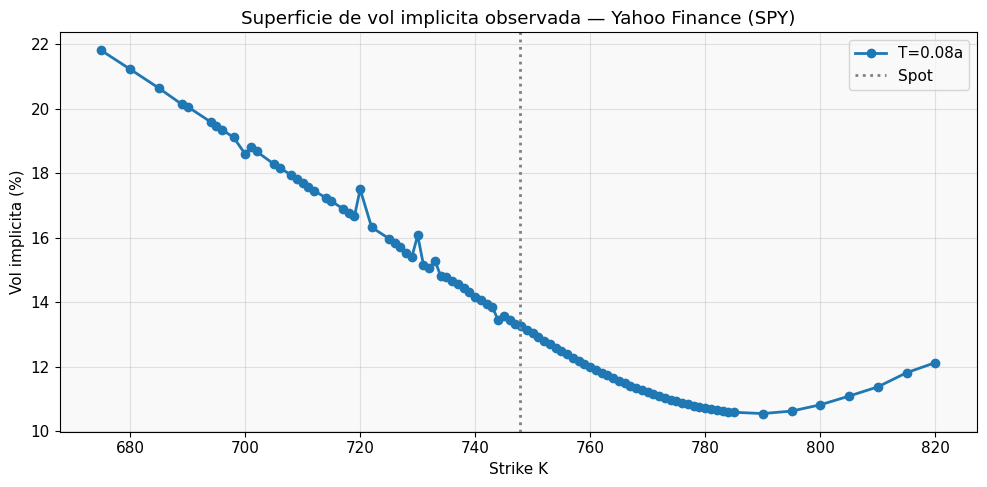

In [5]:
K_col, T_col, mid_col, spread_col, vol_col = 0, 1, 2, 3, 4
moneyness = raw[:, K_col] / S0
mask = (moneyness > 0.90) & (moneyness < 1.10) & (raw[:,mid_col] > 0.05) & (raw[:,T_col] > 30/365) & (raw[:,T_col] < 32/365)

data = raw[mask]

market = [(row[K_col], row[T_col], row[mid_col], row[spread_col]) for row in data]

print(f"Quotes tras limpieza: {len(market)} (de {len(raw)})")
print(f"Fuente: {FUENTE}")

fig, ax = plt.subplots(figsize=(10,5))
for T in sorted(set(row[1] for row in market)):

    Ks  = [row[0] for row in market if row[1]==T]
    ivs = [bs_implied_vol(row[2],S0,row[0],r,row[1])*100 for row in market if row[1]==T]

    orden=np.argsort(Ks)
    ax.plot(np.array(Ks)[orden], np.array(ivs)[orden], 'o-', label=f'T={T:.2f}a')
ax.axvline(S0, color='gray', ls=':', label='Spot')
ax.set_xlabel('Strike K'); ax.set_ylabel('Vol implicita (%)')
ax.set_title(f'Superficie de vol implicita observada — {FUENTE}'); ax.legend()
plt.tight_layout(); plt.show()

## 4. La función de pérdida

Calibrar es minimizar una **función de pérdida** que mide la distancia entre modelo y mercado:

$$\mathcal{L}(\Theta) = \sum_{i=1}^{N} w_i\,\bigl[\,g_{\text{modelo}}(K_i,T_i;\Theta) - g_{\text{mkt}}(K_i,T_i)\,\bigr]^2$$

Usamos error en **precio** ponderado por el inverso del spread al cuadrado: así las opciones con bid-ask apretado (más liquidas, más confiables) pesan más en el ajuste.


In [6]:
def loss(params, market, S0, r):
    v0, theta, kappa, xi, rho = params
    total = 0.0
    for K, T, price_mkt, spread in market:
        try:
            price_mdl = heston_call(S0, K, r, T, v0, kappa, theta, xi, rho)
            w = 1.0 / max(spread, 0.01)**2
            total += w * (price_mdl - price_mkt)**2
        except Exception:  #penalizar datos inválidos
            total += 1e6
    return total

# Prueba con un punto arbitrario
test = (0.04, 0.04, 1.5, 0.5, -0.5)
print("Loss en punto de prueba:", round(loss(test, market, S0, r), 4))


Loss en punto de prueba: 1201985.5183


## 5. Restricciones de parámetros

El optimizador debe respetar el dominio del modelo:

| Parámetro | Restricción | Razón |
|-----------|-------------|-------|
| $v_0$ | $>0$ | varianza positiva |
| $\theta$ | $>0$ | varianza de largo plazo positiva |
| $\kappa$ | $>0$ | reversión (no explosión) |
| $\xi$ | $>0$ | vol-de-vol positiva |
| $\rho$ | $\in(-1,1)$ | correlación valida |

La condición de Feller la dejamos **libre** (no la imponemos): el mercado puede exigir un skew que la viole.


In [7]:
bounds = [
    (0.005, 0.20),   # v0
    (0.005, 0.20),   # theta
    (0.10,  6.00),   # kappa
    (0.05,  1.50),   # xi
    (-0.95, 0.50),   # rho
]
nombres = ['v0','theta','kappa','xi','rho']


## 6. Optimización en dos etapas

La superficie de pérdida es **no convexa**: tiene múltiples mínimos locales y valles planos. Por eso usamos la estrategia estándar en dos etapas:

1. **Búsqueda global** (`differential_evolution`) para encontrar un mínimo local prometedor, aunque sea lento.
2. **Refinamiento local** (`least_squares`, Levenberg-Marquardt) para precisión y velocidad.


In [8]:
from scipy.stats import qmc

print("Etapa 1+2: busqueda global rapida (Latin Hypercube) + refinamiento local (least_squares/TRF)...")

def residuals(params):
    v0,theta,kappa,xi,rho = params
    res=[]
    # lista donde se acumula un residuo por cada opcion del mercado

    for K,T,price_mkt,spread in market:
        # itera sobre cada quote (strike, vencimiento, precio mid, spread)

        w = 1.0/max(spread,0.01)
        # peso por liquidez: inverso del spread (piso de 0.01 para no dividir entre ~0)
        # aqui es 1/spread, no 1/spread^2 como en loss -- least_squares ya eleva el
        # residuo al cuadrado internamente, asi que el cuadrado se aplica una sola vez

        try:
            pm = heston_call(S0,K,r,T,v0,kappa,theta,xi,rho)
            # precio del modelo Heston para esos parametros y ese (K,T)

            res.append(w*(pm - price_mkt))
            # guarda el residuo ponderado: error de precio * peso de liquidez

        except Exception:
            res.append(1e3)
            # si falla la evaluacion (parametros que rompen la integral, etc.),
            # castiga con un residuo grande en vez de tronar el optimizador

    return res
    # regresa el vector completo de residuos (uno por quote)


def busqueda_global_rapida(bounds, market, S0, r, n_candidatos=40, n_refinar=4, seed=1):
    # reemplazo de differential_evolution: escanea el espacio de parametros con
    # pocos puntos, y solo refina localmente los mas prometedores

    lb = np.array([b[0] for b in bounds]); ub = np.array([b[1] for b in bounds])
    # limites inferior y superior de cada parametro, como arrays de numpy

    muestra = qmc.LatinHypercube(d=len(bounds), seed=seed).random(n_candidatos)
    # genera n_candidatos puntos en el cubo unitario [0,1]^5, repartidos de forma
    # uniforme en las 5 dimensiones (mejor cobertura que puntos aleatorios puros
    # para el mismo numero de muestras)

    candidatos = lb + muestra*(ub-lb)
    # escala el cubo [0,1]^5 a los bounds reales de cada parametro (v0,theta,kappa,xi,rho)

    perdidas = [loss(c, market, S0, r) for c in candidatos]
    # evalua la funcion de perdida en cada candidato -- estas son las unicas N
    # evaluaciones "caras" del escaneo global, sin generaciones ni poblaciones repetidas

    mejores_idx = np.argsort(perdidas)[:n_refinar]
    # indices de los n_refinar candidatos con menor perdida (los mas prometedores)

    mejor_fit = None
    # aqui se va guardando el mejor resultado de refinamiento local encontrado

    i = 1
    print(f"Refinando localmente los {n_refinar} mejores candidatos del escaneo global...")
    for idx in mejores_idx:
        # refina localmente cada uno de los candidatos prometedores, no solo el
        # mejor del escaneo -- cubre el riesgo de que el "mejor" del escaneo no
        # sea el que mejor termina convergiendo (valles pianos, minimos cercanos)

        fit = least_squares(residuals, candidatos[idx], bounds=(lb,ub), max_nfev=100)
        print(f"Fit {i} de {n_refinar}: costo={fit.cost*2:.4f}, params={fit.x}")
        i += 1
        # refinamiento local (TRF, por los bounds) arrancando desde ese candidato

        if mejor_fit is None or fit.cost < mejor_fit.cost:
            mejor_fit = fit
            # se queda con el refinamiento que termino en menor costo de los n_refinar

    return mejor_fit
    # regresa el objeto de least_squares con el mejor ajuste encontrado


mejor_fit = busqueda_global_rapida(bounds, market, S0, r, n_candidatos=40, n_refinar=4, seed=1)
# corre todo el proceso: escaneo global barato + refinamiento local sobre los
# candidatos mas prometedores

theta_fit = mejor_fit.x
# guarda los parametros finales calibrados

print("  Loss final:", round(2*mejor_fit.cost, 5))
# mejor_fit.cost es 0.5*suma(residuos^2) (convencion interna de least_squares);
# se multiplica por 2 para reportarlo en las mismas unidades que 'loss'

print("  Params calibrados:", {n: round(v,4) for n,v in zip(nombres, theta_fit)})
# imprime los parametros finales, emparejados con sus nombres

Etapa 1+2: busqueda global rapida (Latin Hypercube) + refinamiento local (least_squares/TRF)...
Refinando localmente los 4 mejores candidatos del escaneo global...
Fit 1 de 4: costo=34.9603, params=[ 5.00000004e-03  7.54979008e-02  5.99999919e+00  1.06352651e+00
 -6.70847377e-01]
Fit 2 de 4: costo=35.5904, params=[ 0.00500023  0.10161186  4.14950954  1.00769565 -0.67464643]
Fit 3 de 4: costo=34.9603, params=[ 5.00000000e-03  7.54982018e-02  6.00000000e+00  1.06353669e+00
 -6.70847627e-01]
Fit 4 de 4: costo=35.4698, params=[ 0.00500148  0.09533259  4.48105415  1.0176034  -0.67393827]
  Loss final: 34.96032
  Params calibrados: {'v0': np.float64(0.005), 'theta': np.float64(0.0755), 'kappa': np.float64(6.0), 'xi': np.float64(1.0635), 'rho': np.float64(-0.6708)}


## 7. Evaluación del ajuste

Comparamos la sonrisa del modelo calibrado contra la observada, por vencimiento. Deben superponerse. Reportamos también el RMSE en puntos de volatilidad.


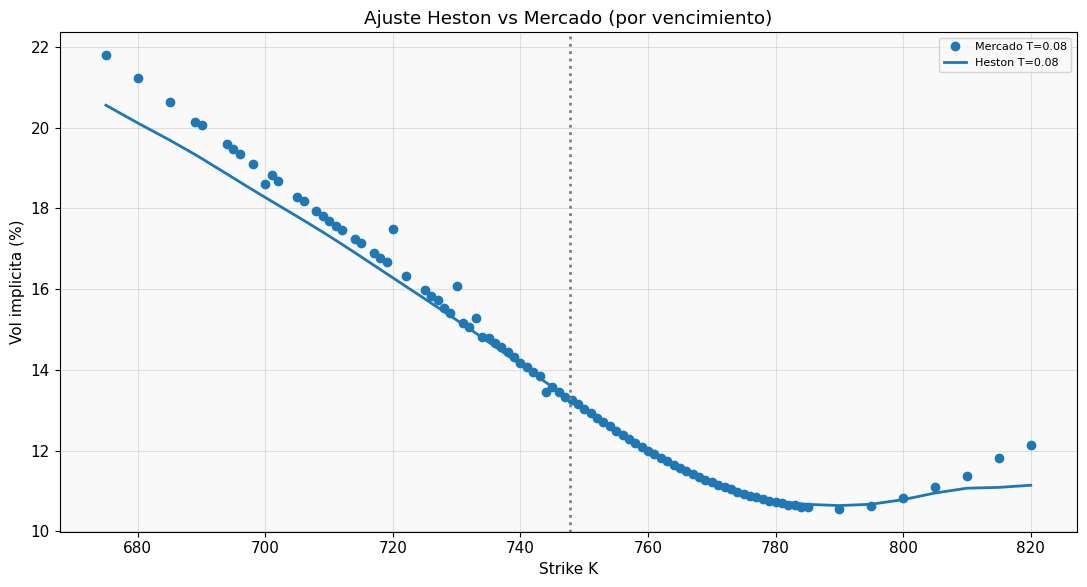

RMSE del ajuste: 0.382 puntos de volatilidad
Condicion de Feller: VIOLADA (2*kappa*theta=0.906, xi^2=1.131)


In [10]:
fig, ax = plt.subplots(figsize=(11,6))
errores = []
for T in sorted(set(row[1] for row in market)):
    filas_T = [row for row in market if row[1]==T]
    Ks = np.array([row[0] for row in filas_T]); orden=np.argsort(Ks); Ks=Ks[orden]
    iv_mkt = np.array([bs_implied_vol(row[2],S0,row[0],r,T)*100 for row in filas_T])[orden]
    iv_mdl = []
    for K in Ks:
        pm = heston_call(S0,K,r,T,theta_fit[0],theta_fit[2],theta_fit[1],theta_fit[3],theta_fit[4])
        iv_mdl.append(bs_implied_vol(pm,S0,K,r,T)*100)
    iv_mdl=np.array(iv_mdl)
    errores.extend(iv_mdl - iv_mkt)
    l=ax.plot(Ks, iv_mkt, 'o', label=f'Mercado T={T:.2f}')[0]
    ax.plot(Ks, iv_mdl, '-', color=l.get_color(), label=f'Heston T={T:.2f}')
ax.axvline(S0, color='gray', ls=':')
ax.set_xlabel('Strike K'); ax.set_ylabel('Vol implicita (%)')
ax.set_title('Ajuste Heston vs Mercado (por vencimiento)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

rmse = np.sqrt(np.mean(np.array(errores)**2))
print(f"RMSE del ajuste: {rmse:.3f} puntos de volatilidad")
feller = 2*theta_fit[2]*theta_fit[1] >= theta_fit[3]**2
print(f"Condicion de Feller: {'CUMPLE' if feller else 'VIOLADA'} "
      f"(2*kappa*theta={2*theta_fit[2]*theta_fit[1]:.3f}, xi^2={theta_fit[3]**2:.3f})")